# **Project Title:-** Charting the Loyalty Curve: A Sophisticated OLS Linear Regression Insight Into Consumer Satisfaction

# **What is Linear Regression?**
Linear Regression is a method used to model the relationship between:

* **One dependent variable (Y) →** the output you want to predict

* **One or more independent variables (X) →** the inputs used for prediction

It assumes that this relationship can be represented by a straight line.

###**Mathematical Form:**
For Simple Linear Regression:
**y = mx + c**

Where,
* **y →** predicted value

* **x →** input variable

* **c →** intercept (value of Y when X = 0)

* **m →** slope (how much Y changes when X changes by 1 unit)
                

# **Ordinary Least Squares (OLS)**

Ordinary Least Squares (OLS) is a method used in linear regression to find the best-fitting straight line through a set of data points.
The goal of OLS is to estimate two parameters:

* **a →** intercept

* **b →** slope

These are used to model the relationship:

##**𝑌 = 𝑏𝑋 + 𝑎**

This equation is equivalent to the standard mathematical form:

##**𝑦 = 𝑚𝑥 + 𝑐**

Where:

* **b = m → slope**

* **a = c → intercept**

# **Loss Function (Squared Error Function)**

OLS minimizes the sum of squared errors, where the error is the vertical distance between actual and predicted values.

**The loss (or cost) function is:**

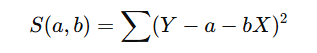

This represents the total squared difference between the observed **Y** and the predicted value **(bX + a)**.



# **Problems of using Normal Linear Regression**

In the normal linear regression (manual method), we usually pick only two points on the graph to calculate:

* **the slope (m)**

* **the intercept (c)**

This approach is problematic because:

1. **It uses only two data points**

The slope and intercept are calculated based only on two observations, even though the dataset might have hundreds of points.
This leads to an inaccurate, unstable line.

2. **The intercept is often estimated visually**

When manually drawing a line, the intercept is guessed by looking at where the line crosses the Y-axis.
This introduces human error.

3. **Squaring the error increases the problem**

When we calculate the difference between Actual Y and Predicted Y, we get an error value.
Squaring these errors can make the line even more sensitive to the specific two points chosen.

As a result, using only two points gives a poorly fitted line and a high error.

# **How OLS (Ordinary Least Squares) Fixes These Problems**

OLS does not rely on just two points.
Instead, it:

**Uses every single data point in the dataset**

The method considers all values of X and Y to compute the slope and intercept.

Because it uses all points, OLS finds a line that is:

* **more accurate**

* **more stable**

* **better fitting**

* **less sensitive to noise**

This is why OLS produces the **best-fitted straight** line for the given dataset.

# **Why We Use Partial Derivatives in OLS**

The OLS error (loss) function is:

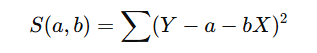

This function depends on **two variables**:

* **a →** intercept

* **b →** slope

To **minimize** this error function, we need to find the optimal values of both a and b.

**Because the function has TWO variables, we must use partial derivatives, not ordinary derivatives.**

Here is the correct interpretation:

## **Partial derivative of S with respect to a**

When we differentiate with respect to **a**, we treat **b as constant**.
This tells us how S changes if we slightly adjust the intercept.

## **Partial derivative of S with respect to b**

When we differentiate with respect to **b**, we treat **a as constant**.
This tells us how S changes if we slightly adjust the slope.

This is the meaning of:

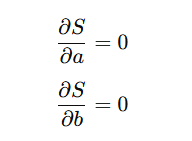

**We set them equal to zero because a minimum error occurs when the slope of the error function becomes zero.**

This gives us two equations (called **normal equations**) from which we solve for a and b.

# **Why Do We Set the Derivatives to 0?**

To minimize the loss function, we follow calculus optimization rules:

A function reaches a minimum when its derivative is zero.

**So we solve:**

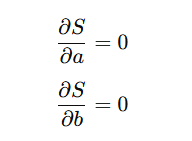

These two equations (called normal equations) give the values of a and b that produce the smallest possible error.

**In simple words:**

* We set partial derivatives to zero because it gives the values of a and b that minimize the total error.

# **Formula for Slope (b)**

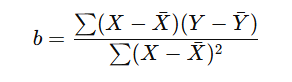

This formula tells us how much **Y** changes when **X** increases by **1 unit**.

# **Formula for Intercept (a)**

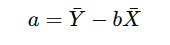

This is the value of **Y** when **X = 0**.

# **Introduction to the Dataset**

The **Customer Satisfaction vs Repeat Purchases** dataset is designed to analyze how a customer's satisfaction level influences their likelihood of making repeat purchases. In today’s competitive business environment, understanding customer behavior is essential for building loyalty, improving service quality, and increasing long-term profitability. This dataset captures two key variables:

* **Customer Satisfaction Score (X) –** a numerical rating given by customers based on their overall experience, product quality, and service satisfaction.

* **Repeat Purchase Count (Y) –** the number of times the same customer makes additional purchases after the initial transaction.

The main objective of this dataset is to explore and quantify the relationship between customer satisfaction and repeat buying behavior. Using statistical modeling—specifically **Ordinary Least Squares (OLS) Linear Regression** — the dataset helps in determining whether higher satisfaction scores lead to more repeat purchases and how strongly the two variables are connected.

# **Importing the Libraries**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
# We can override the default matplotlib styles with those of Seaborn
#import seaborn as sns
#sns.set()

# **Loading the Data**

In [17]:
# Load the data from a .csv in the same folder
data = pd.read_csv('Customer_Satisfaction_vs_Repeat_Purchases.csv')

In [18]:
# Let's check what's inside this data frame
data

,Satisfaction,Repeat_Purchases
0,62.47,10
1,97.04,18
2,83.92,16
3,75.92,13
4,49.36,12
...,...,...
94,86.26,15
95,69.63,12
96,71.36,15
97,65.65,12


# **Tabular Analysis**

In [19]:
# This method gives us very nice descriptive statistics. We don't need this as of now, but will later on!
data.describe()

,Satisfaction,Repeat_Purchases
count,99.000000,99.000000
mean,68.429899,12.515152
std,17.803751,3.411755
min,40.330000,6.000000
25%,51.840000,10.000000
50%,68.330000,12.000000
75%,83.850000,15.000000
max,99.210000,19.000000


# **Decide Dependent and Independent Elements in Dataset**

In [20]:
# Following the regression equation, our dependent variable (y) is the GPA
y = data ['Repeat_Purchases']
# Similarly, our independent variable (x) is the SAT score
x = data ['Satisfaction']

# **Exploring the data by Data Visualization - Linear Regression**

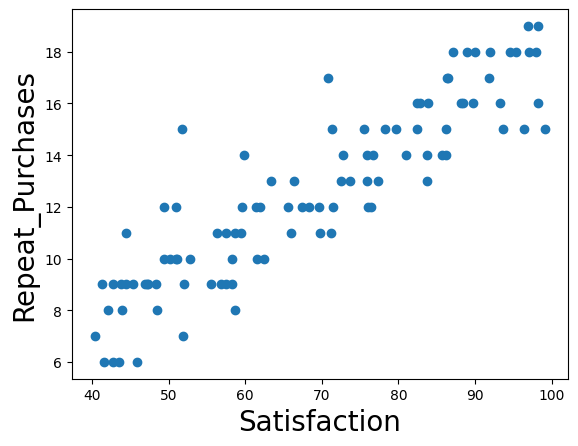

In [21]:
# Plot a scatter plot (first we put the horizontal axis, then the vertical axis)
plt.scatter(x,y)
# Name the axes
plt.xlabel('Satisfaction', fontsize = 20)
plt.ylabel('Repeat_Purchases', fontsize = 20)
# Show the plot
plt.show()

# **Train the Model and print the Summary of the Regression**

In [22]:
# Add a constant. Essentially, we are adding a new column (equal in lenght to x1), which consists only of 1s
x1 = sm.add_constant(x)
# Fit the model, according to the OLS (ordinary least squares) method with a dependent variable y and an idependent x1
results = sm.OLS(y,x1).fit()
# Print a nice summary of the regression. That's one of the strong points of statsmodels -> the summaries
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Repeat_Purchases   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     403.1
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           2.55e-36
Time:                        14:43:11   Log-Likelihood:                -180.28
No. Observations:                  99   AIC:                             364.6
Df Residuals:                      97   BIC:                             369.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7420      0.606      1.225      0.224      -0.460       1.944
Satisfaction     0.1720      0.009     20.078      0.000       0.155       0.189
==============================================================================
Omnibus:                        6.657   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.036   Jarque-Bera (JB):                6.363
Skew:                           0.479   Prob(JB):                       0.0415
Kurtosis:                       3.791   Cond. No.                         282.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# **Predicting the best fit line by defining the rgression equation**

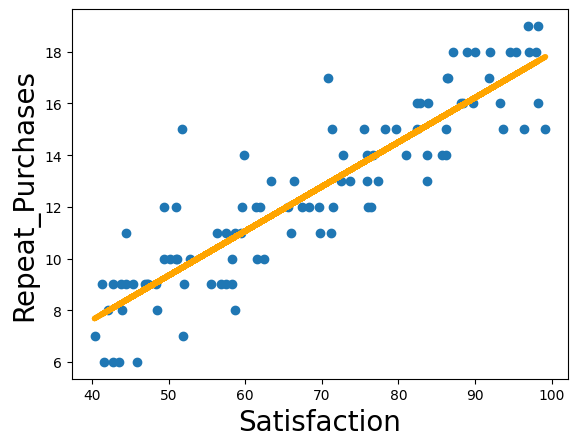

In [23]:
# Create a scatter plot
plt.scatter(x,y)
# Define the regression equation, so we can plot it later
yhat = 0.1720*x + 0.7420
# Plot the regression line against the independent variable (SAT)
fig = plt.plot(x,yhat, lw=4, c='orange', label ='regression line')
# Label the axes
plt.xlabel('Satisfaction', fontsize = 20)
plt.ylabel('Repeat_Purchases', fontsize = 20)
plt.show()

# **OLS (Ordinary Least Square Method) - Conclusion**

* The OLS Linear Regression model shows a **positive relationship** between customer satisfaction and repeat purchases.

* As satisfaction scores increase, customers are **more likely to make repeat purchases**.

* OLS provides accurate estimates because it **uses all data points**, reducing error and improving model reliability.

* The best-fit line indicates that **customer satisfaction is a strong predictor of loyalty**.

* Businesses can use these insights to **improve customer experience and boost retention**.